<a href="https://colab.research.google.com/github/Najaf-14/Computer-Vision/blob/main/ANN%26DL_Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

class Perceptron:
    def __init__(self, N, alpha=0.1):
        self.W = np.random.randn(N + 1) / np.sqrt(N)
        self.alpha = alpha

    def step(self, x):
        return 1 if x > 0 else 0

    def fit(self, X, y, epochs=10):
        X = np.c_[X, np.ones((X.shape[0]))]

        for epoch in np.arange(0, epochs):
            for x, target in zip(X, y):
                p = self.step(np.dot(x, self.W))

                if p != target:
                    error = p - target

                    self.W += -self.alpha * error * x

    def predict(self, X, addBias=True):
        X = np.atleast_2d(X)

        if addBias:
            X = np.c_[X, np.ones((X.shape[0]))]

        return self.step(np.dot(X, self.W))

print("--- Training on OR Dataset ---")
X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_or = np.array([[0], [1], [1], [1]])

print("[INFO] training perceptron...")
p_or = Perceptron(X_or.shape[1], alpha=0.1)
p_or.fit(X_or, y_or, epochs=20)

print("[INFO] testing perceptron...")
for x, target in zip(X_or, y_or):
    pred = p_or.predict(x)
    print(
        "[INFO] data={}, ground-truth={}, pred={}".format(
            x, target[0], pred
        )
    )

print("\n--- Training on XOR Dataset ---")
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([[0], [1], [1], [0]])

print("[INFO] training perceptron...")
p_xor = Perceptron(X_xor.shape[1], alpha=0.1)
p_xor.fit(X_xor, y_xor, epochs=20)

print("[INFO] testing perceptron...")
for x, target in zip(X_xor, y_xor):
    pred = p_xor.predict(x)
    print(
        "[INFO] data={}, ground-truth={}, pred={}".format(
            x, target[0], pred
        )
    )

--- Training on OR Dataset ---
[INFO] training perceptron...
[INFO] testing perceptron...
[INFO] data=[0 0], ground-truth=0, pred=0
[INFO] data=[0 1], ground-truth=1, pred=1
[INFO] data=[1 0], ground-truth=1, pred=1
[INFO] data=[1 1], ground-truth=1, pred=1

--- Training on XOR Dataset ---
[INFO] training perceptron...
[INFO] testing perceptron...
[INFO] data=[0 0], ground-truth=0, pred=0
[INFO] data=[0 1], ground-truth=1, pred=0
[INFO] data=[1 0], ground-truth=1, pred=0
[INFO] data=[1 1], ground-truth=0, pred=0


       0    1    2    3               4
0    5.1  3.5  1.4  0.2     Iris-setosa
1    4.9  3.0  1.4  0.2     Iris-setosa
2    4.7  3.2  1.3  0.2     Iris-setosa
3    4.6  3.1  1.5  0.2     Iris-setosa
4    5.0  3.6  1.4  0.2     Iris-setosa
..   ...  ...  ...  ...             ...
145  6.7  3.0  5.2  2.3  Iris-virginica
146  6.3  2.5  5.0  1.9  Iris-virginica
147  6.5  3.0  5.2  2.0  Iris-virginica
148  6.2  3.4  5.4  2.3  Iris-virginica
149  5.9  3.0  5.1  1.8  Iris-virginica

[150 rows x 5 columns]


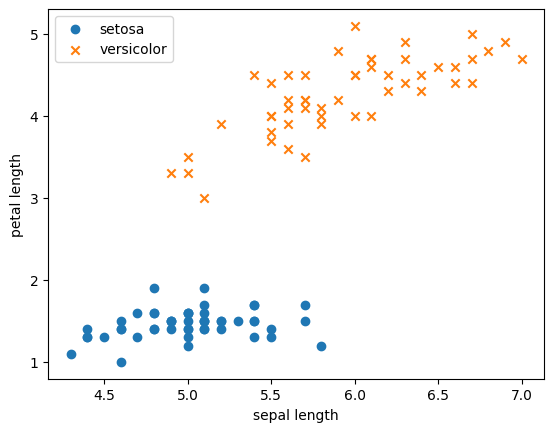

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def load_data():
    URL_ = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'

    data = pd.read_csv(URL_, header=None)

    print(data)

    data = data.iloc[:100].copy()

    data = data.reset_index(drop=True)

    data.iloc[:, 4] = np.where(
        data.iloc[:, 4] == 'Iris-setosa',
        0,
        1
    )

    data = np.asmatrix(data, dtype='float64')

    return data

data = load_data()

plt.scatter(
    np.array(data[:50, 0]),
    np.array(data[:50, 2]),
    marker='o',
    label='setosa'
)

plt.scatter(
    np.array(data[50:, 0]),
    np.array(data[50:, 2]),
    marker='x',
    label='versicolor'
)

plt.xlabel('sepal length')
plt.ylabel('petal length')

plt.legend()
plt.show()

Dataset:
[[5.1 3.5 1.4 0.2 0. ]
 [4.9 3.  1.4 0.2 0. ]
 [4.7 3.2 1.3 0.2 0. ]
 [4.6 3.1 1.5 0.2 0. ]
 [5.  3.6 1.4 0.2 0. ]
 [5.4 3.9 1.7 0.4 0. ]
 [4.6 3.4 1.4 0.3 0. ]
 [5.  3.4 1.5 0.2 0. ]
 [4.4 2.9 1.4 0.2 0. ]
 [4.9 3.1 1.5 0.1 0. ]
 [5.4 3.7 1.5 0.2 0. ]
 [4.8 3.4 1.6 0.2 0. ]
 [4.8 3.  1.4 0.1 0. ]
 [4.3 3.  1.1 0.1 0. ]
 [5.8 4.  1.2 0.2 0. ]
 [5.7 4.4 1.5 0.4 0. ]
 [5.4 3.9 1.3 0.4 0. ]
 [5.1 3.5 1.4 0.3 0. ]
 [5.7 3.8 1.7 0.3 0. ]
 [5.1 3.8 1.5 0.3 0. ]
 [5.4 3.4 1.7 0.2 0. ]
 [5.1 3.7 1.5 0.4 0. ]
 [4.6 3.6 1.  0.2 0. ]
 [5.1 3.3 1.7 0.5 0. ]
 [4.8 3.4 1.9 0.2 0. ]
 [5.  3.  1.6 0.2 0. ]
 [5.  3.4 1.6 0.4 0. ]
 [5.2 3.5 1.5 0.2 0. ]
 [5.2 3.4 1.4 0.2 0. ]
 [4.7 3.2 1.6 0.2 0. ]
 [4.8 3.1 1.6 0.2 0. ]
 [5.4 3.4 1.5 0.4 0. ]
 [5.2 4.1 1.5 0.1 0. ]
 [5.5 4.2 1.4 0.2 0. ]
 [4.9 3.1 1.5 0.1 0. ]
 [5.  3.2 1.2 0.2 0. ]
 [5.5 3.5 1.3 0.2 0. ]
 [4.9 3.1 1.5 0.1 0. ]
 [4.4 3.  1.3 0.2 0. ]
 [5.1 3.4 1.5 0.2 0. ]
 [5.  3.5 1.3 0.3 0. ]
 [4.5 2.3 1.3 0.3 0. ]
 [4.4 3.2 1.3 0.2 0. ]
 [

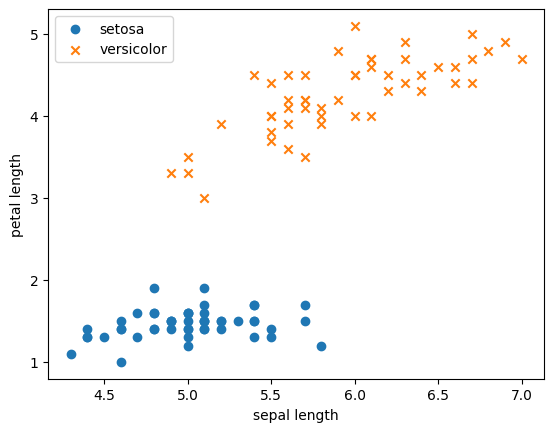

Final weights:
[[-1.  -1.1 -3.6  5.2  2.2]]
Misclassified in each epoch:
[1, 3, 1, 0, 0, 0, 0, 0, 0, 0]


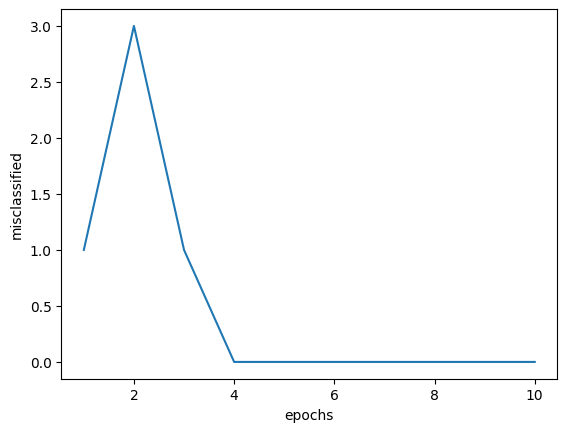

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# Activity 1: Load Dataset
# =========================

def load_data():

    URL_ = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'

    # Load dataset
    data = pd.read_csv(URL_, header=None)

    # Keep only Setosa and Versicolor
    data = data.iloc[:100].copy()

    # Reset index
    data = data.reset_index(drop=True)

    # Convert classes:
    # Iris-setosa = 0
    # Iris-versicolor = 1
    data.iloc[:, 4] = np.where(
        data.iloc[:, 4] == 'Iris-setosa',
        0,
        1
    )

    # Convert to NumPy matrix
    data = np.asmatrix(data, dtype='float64')

    return data


# Load data
data = load_data()

print("Dataset:")
print(data)


# =========================
# Visualize Dataset
# =========================

plt.scatter(
    np.array(data[:50, 0]),
    np.array(data[:50, 2]),
    marker='o',
    label='setosa'
)

plt.scatter(
    np.array(data[50:, 0]),
    np.array(data[50:, 2]),
    marker='x',
    label='versicolor'
)

plt.xlabel('sepal length')
plt.ylabel('petal length')

plt.legend()
plt.show()


# =========================
# Activity 2: Perceptron
# =========================

def perceptron(data, num_iter):

    # Separate features and labels
    features = data[:, :-1]
    labels = data[:, -1]

    # Set weights to zero
    # 4 features + 1 bias = 5 weights
    w = np.zeros(shape=(1, features.shape[1] + 1))

    # Store number of misclassified samples
    misclassified_ = []

    # Training epochs
    for epoch in range(num_iter):

        misclassified = 0

        # Go through each training example
        for x, label in zip(features, labels):

            # Add bias input
            x = np.insert(x, 0, 1)

            # Calculate weighted sum
            y = np.dot(w, x.transpose())

            # Apply threshold
            target = 1.0 if (y > 0) else 0.0

            # Calculate error
            delta = label.item(0, 0) - target

            # If misclassified
            if delta:

                misclassified += 1

                # Update weights
                w += delta * x

        # Store mistakes of this epoch
        misclassified_.append(misclassified)

    return w, misclassified_


# =========================
# Train Perceptron
# =========================

num_iter = 10

w, misclassified_ = perceptron(data, num_iter)

print("Final weights:")
print(w)

print("Misclassified in each epoch:")
print(misclassified_)


# =========================
# Plot Perceptron Results
# =========================

epochs = np.arange(1, num_iter + 1)

plt.plot(epochs, misclassified_)

plt.xlabel('epochs')
plt.ylabel('misclassified')

plt.show()